# Census Income Prediction — ML Pipeline
**Study Case: AI Engineering — Laboratorium Big Data Universitas Telkom**

Notebook ini berisi pipeline end-to-end untuk memprediksi kategori pendapatan (`income`: `<=50K` atau `>50K`) menggunakan Adult/Census Income Dataset.

## Struktur Notebook
1. Import & Load Data
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Feature Engineering
5. Modeling & Eksperimen
6. Evaluasi Model
7. Analisis Hasil & Kesimpulan


## 1. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (39073, 15)
Test shape: (9769, 15)


## 2. Exploratory Data Analysis (EDA)

### 2.1 Struktur Dasar Dataset

In [2]:
train.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,37,Private,193106,Bachelors,13,Never-married,Sales,Not-in-family,White,Female,0,0,30,United-States,<=50K.
1,56,Self-emp-inc,216636,12th,8,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1651,40,United-States,<=50K
2,53,Private,126977,HS-grad,9,Separated,Craft-repair,Not-in-family,White,Male,0,0,35,United-States,<=50K
3,72,Private,205343,11th,7,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
4,46,State-gov,106705,Masters,14,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,38,United-States,<=50K


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 39073 entries, 0 to 39072
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             39073 non-null  int64
 1   workclass       38304 non-null  str  
 2   fnlwgt          39073 non-null  int64
 3   education       39073 non-null  str  
 4   education-num   39073 non-null  int64
 5   marital-status  39073 non-null  str  
 6   occupation      38302 non-null  str  
 7   relationship    39073 non-null  str  
 8   race            39073 non-null  str  
 9   sex             39073 non-null  str  
 10  capital-gain    39073 non-null  int64
 11  capital-loss    39073 non-null  int64
 12  hours-per-week  39073 non-null  int64
 13  native-country  38851 non-null  str  
 14  income          39073 non-null  str  
dtypes: int64(6), str(9)
memory usage: 4.5 MB


**Catatan:**
- Dataset memiliki 39.073 baris dan 15 kolom (14 fitur + 1 target `income`).
- Fitur numerik: `age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`.
- Fitur kategorikal: `workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`.
- `fnlwgt` (final weight) adalah bobot sampling sensus, bukan atribut individu — perlu dipertimbangkan apakah relevan sebagai fitur prediktif.

### 2.2 Pemeriksaan Kualitas Data (Missing Values, Duplikat, Konsistensi Label)

In [4]:
# Cek missing values
missing = train.isna().sum()
missing = missing[missing > 0]
print("Missing values per kolom:")
print(missing)
print(f"\nPersentase dari total baris ({len(train)}):")
print((missing / len(train) * 100).round(2))

Missing values per kolom:
workclass         769
occupation        771
native-country    222
dtype: int64

Persentase dari total baris (39073):
workclass         1.97
occupation        1.97
native-country    0.57
dtype: float64


In [5]:
# Cek duplikat
n_dup = train.duplicated().sum()
print(f"Jumlah baris duplikat penuh: {n_dup}")
print(f"Persentase: {n_dup/len(train)*100:.3f}%")

Jumlah baris duplikat penuh: 21
Persentase: 0.054%


In [6]:
# Cek konsistensi label target
print("Distribusi nilai unik kolom 'income' (SEBELUM dibersihkan):")
print(train['income'].value_counts())

Distribusi nilai unik kolom 'income' (SEBELUM dibersihkan):
income
<=50K     19733
<=50K.     9991
>50K       6306
>50K.      3043
Name: count, dtype: int64


**Temuan:**
1. **Missing values** ditemukan pada 3 kolom kategorikal: `workclass` (769 baris), `occupation` (771 baris), `native-country` (222 baris). Totalnya relatif kecil (<2% dari total data), tapi tetap perlu ditangani sebelum modeling karena sebagian besar algoritma ML tidak bisa menerima nilai `NaN` secara langsung.
2. **Duplikat**: ada 21 baris duplikat penuh. Kemungkinan berasal dari penggabungan dua sumber data (lihat poin 3).
3. **Label `income` tidak konsisten** — ada 4 varian: `<=50K`, `<=50K.`, `>50K`, `>50K.`. Ini adalah karakteristik umum dataset Adult/Census Income UCI, di mana versi "train" asli menyimpan label tanpa titik, sedangkan versi "test" asli menyimpan label dengan titik di akhir. Sepertinya kedua sumber ini digabung menjadi satu file `train.csv`. **Ini WAJIB dinormalisasi (hapus titik) sebelum encoding**, karena jika tidak, model akan salah menganggap ada 4 kelas target, bukan 2.

### 2.3 Normalisasi Target & Distribusi Kelas

In [7]:
# Normalisasi label income: hapus titik di akhir, strip whitespace
train['income'] = train['income'].str.strip().str.rstrip('.')

print("Distribusi 'income' SETELAH dinormalisasi:")
print(train['income'].value_counts())
print()
print("Proporsi (%):")
print((train['income'].value_counts(normalize=True) * 100).round(2))

Distribusi 'income' SETELAH dinormalisasi:
income
<=50K    29724
>50K      9349
Name: count, dtype: int64

Proporsi (%):
income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


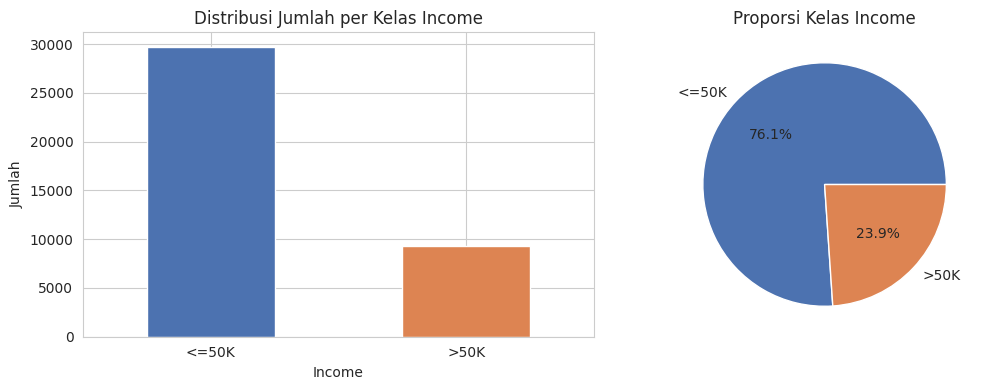

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

train['income'].value_counts().plot(kind='bar', ax=ax[0], color=['#4C72B0', '#DD8452'])
ax[0].set_title('Distribusi Jumlah per Kelas Income')
ax[0].set_xlabel('Income')
ax[0].set_ylabel('Jumlah')
ax[0].tick_params(axis='x', rotation=0)

train['income'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
                                      colors=['#4C72B0', '#DD8452'], ylabel='')
ax[1].set_title('Proporsi Kelas Income')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

**Temuan:**
- Setelah normalisasi, target `income` hanya memiliki 2 kelas seperti yang diharapkan: `<=50K` (~76%) dan `>50K` (~24%).
- Dataset **imbalanced** dengan rasio kira-kira 3:1. Kelas mayoritas (`<=50K`) mendominasi.
- Implikasi untuk pemodelan:
  - **Accuracy** bisa menyesatkan sebagai metrik evaluasi tunggal (model yang selalu menebak `<=50K` saja sudah bisa dapat accuracy ~76%). Ini sejalan dengan ketentuan soal yang mewajibkan **F1-macro** sebagai metrik evaluasi, karena F1-macro memberi bobot setara ke kedua kelas, tidak bias ke kelas mayoritas.
  - Perlu dipertimbangkan strategi penanganan imbalance saat modeling: `class_weight='balanced'`, teknik resampling (oversampling/undersampling), atau memilih algoritma yang robust terhadap imbalance.

### 2.4 Eksplorasi Fitur Numerik

In [9]:
num_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,39073.0,38.643488,13.685634,17.0,28.0,37.0,48.0,90.0
fnlwgt,39073.0,189992.238758,105476.844437,13769.0,117767.0,178615.0,238329.0,1490400.0
education-num,39073.0,10.069844,2.574387,1.0,9.0,10.0,12.0,16.0
capital-gain,39073.0,1038.040540,7204.953114,0.0,0.0,0.0,0.0,99999.0
capital-loss,39073.0,86.807949,401.276773,0.0,0.0,0.0,0.0,4356.0
hours-per-week,39073.0,40.476877,12.401251,1.0,40.0,40.0,45.0,99.0


**Catatan awal dari statistik deskriptif:**
- `capital-gain` dan `capital-loss` memiliki median 0 dan std yang jauh lebih besar dari mean → sangat **skewed**, mayoritas orang tidak punya capital gain/loss, tapi ada sebagian kecil dengan nilai sangat tinggi (outlier struktural, bukan noise).
- `age` berkisar wajar (masa kerja produktif).
- `fnlwgt` punya rentang sangat besar (ribuan hingga jutaan) — ini bobot sampling sensus, bukan atribut personal individu, sehingga relevansinya sebagai fitur prediktif perlu dipertimbangkan ulang saat feature engineering.

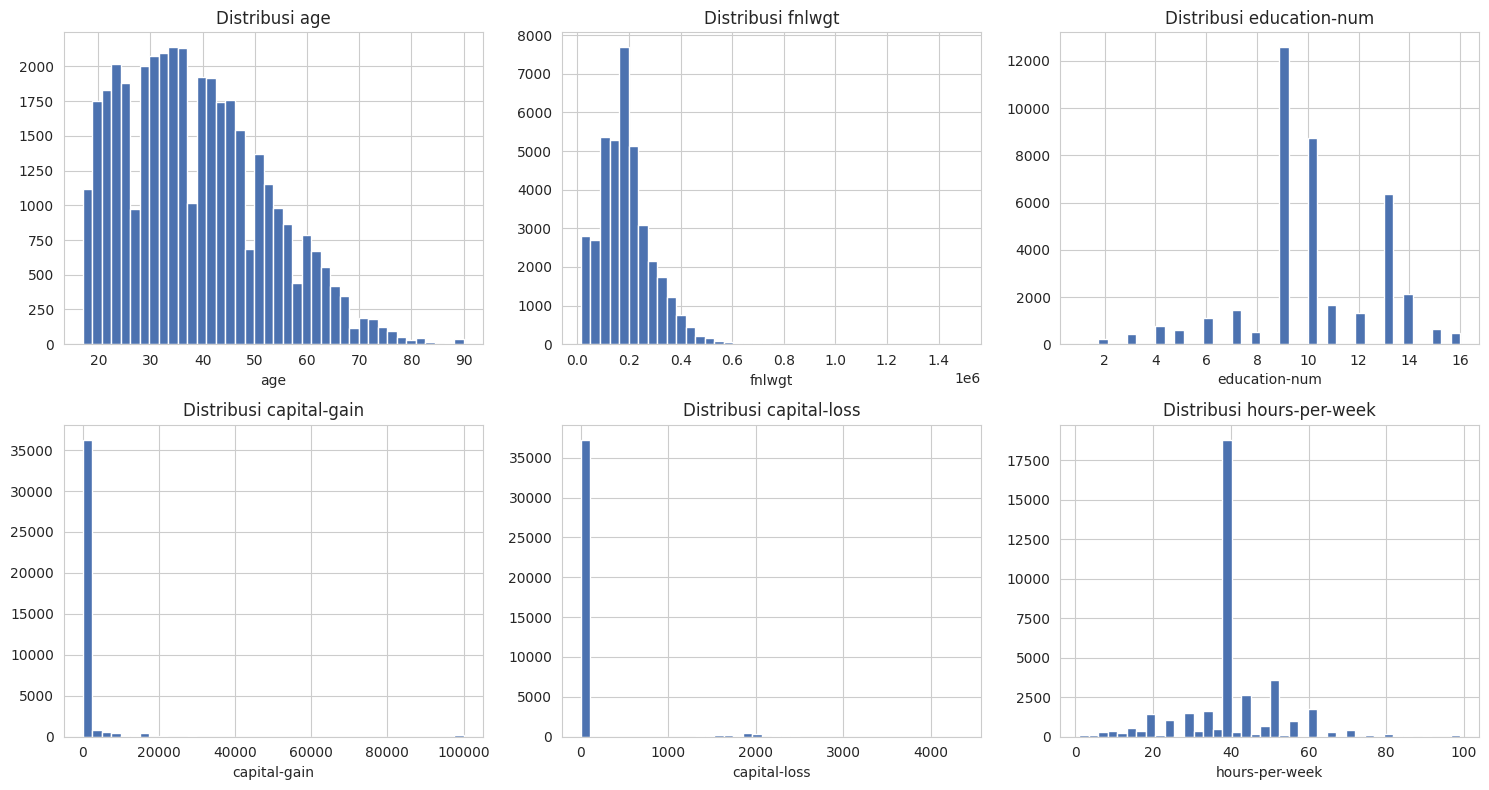

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(train[col], bins=40, color='#4C72B0', edgecolor='white')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.savefig('eda_numeric_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

/tmp/ipykernel_491/329108373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='income', y=col, ax=axes[i], palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_491/329108373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='income', y=col, ax=axes[i], palette=['#4C72B0', '#DD8452'])


/tmp/ipykernel_491/329108373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='income', y=col, ax=axes[i], palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_491/329108373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='income', y=col, ax=axes[i], palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_491/329108373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='income', y=col, ax=axes[i], palette=['#4C72B0', '#DD8452'])


/tmp/ipykernel_491/329108373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='income', y=col, ax=axes[i], palette=['#4C72B0', '#DD8452'])


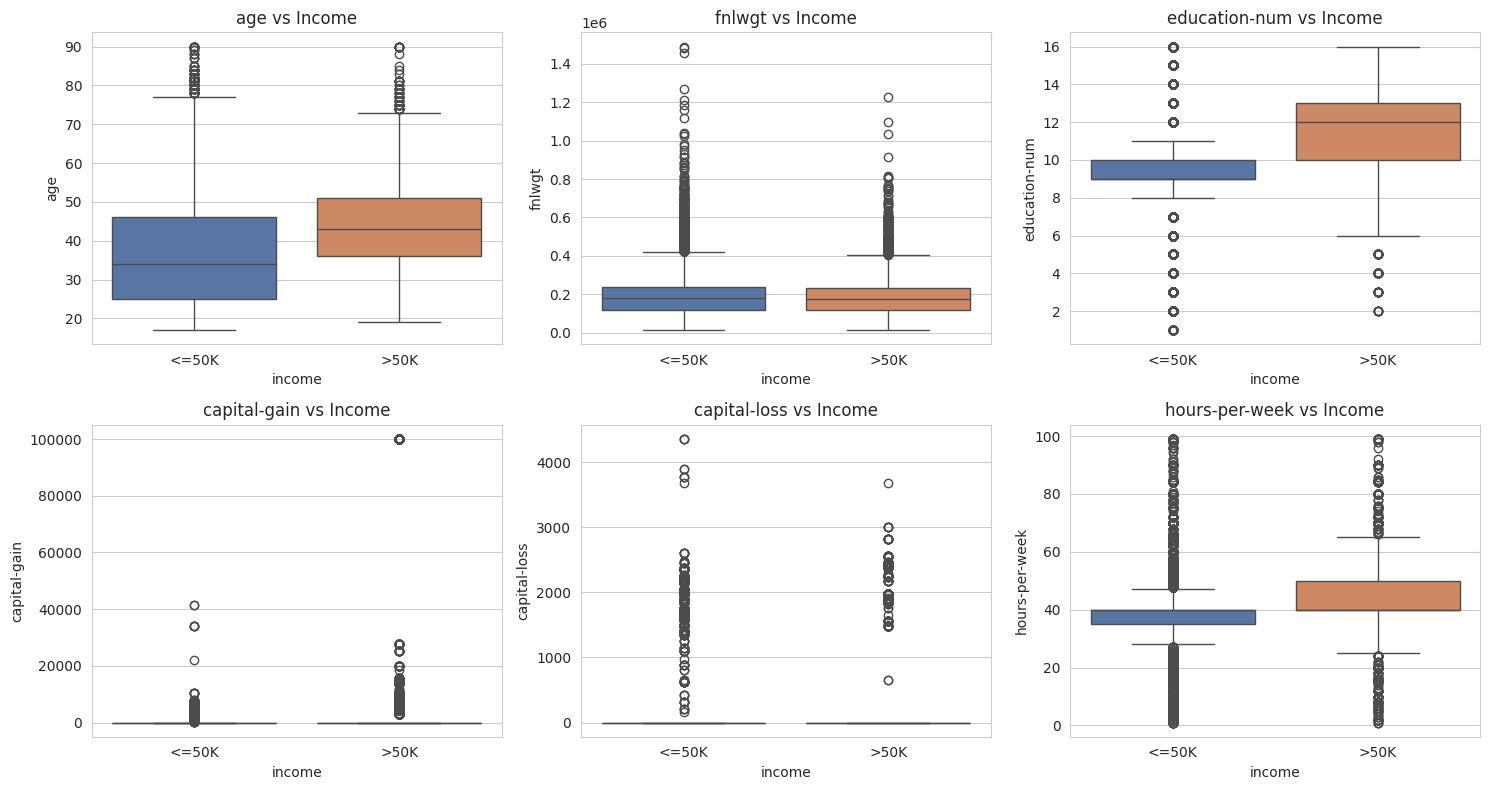

In [11]:
# Hubungan fitur numerik dengan target
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=train, x='income', y=col, ax=axes[i], palette=['#4C72B0', '#DD8452'])
    axes[i].set_title(f'{col} vs Income')

plt.tight_layout()
plt.savefig('eda_numeric_vs_target.png', dpi=100, bbox_inches='tight')
plt.show()

### 2.5 Eksplorasi Fitur Kategorikal

In [12]:
cat_cols = ['workclass', 'education', 'marital-status', 'occupation',
            'relationship', 'race', 'sex', 'native-country']

print("Jumlah nilai unik per kolom kategorikal:")
for col in cat_cols:
    print(f"  {col}: {train[col].nunique()} kategori")

Jumlah nilai unik per kolom kategorikal:
  workclass: 9 kategori
  education: 16 kategori
  marital-status: 7 kategori
  occupation: 15 kategori
  relationship: 6 kategori
  race: 5 kategori
  sex: 2 kategori
  native-country: 42 kategori


In [13]:
for col in cat_cols:
    print(f"--- {col} ---")
    print(train[col].value_counts(dropna=False).head(10))
    print()

--- workclass ---
workclass
Private             27141
Self-emp-not-inc     3068
Local-gov            2535
State-gov            1556
?                    1464
Self-emp-inc         1363
Federal-gov          1150
NaN                   769
Without-pay            19
Never-worked            8
Name: count, dtype: int64

--- education ---
education
HS-grad         12582
Some-college     8739
Bachelors        6379
Masters          2131
Assoc-voc        1657
11th             1451
Assoc-acdm       1303
10th             1108
7th-8th           756
Prof-school       654
Name: count, dtype: int64

--- marital-status ---
marital-status
Married-civ-spouse       17951
Never-married            12835
Divorced                  5298
Separated                 1233
Widowed                   1226
Married-spouse-absent      502
Married-AF-spouse           28
Name: count, dtype: int64

--- occupation ---
occupation
Prof-specialty       4915
Exec-managerial      4893
Craft-repair         4872
Adm-clerical        

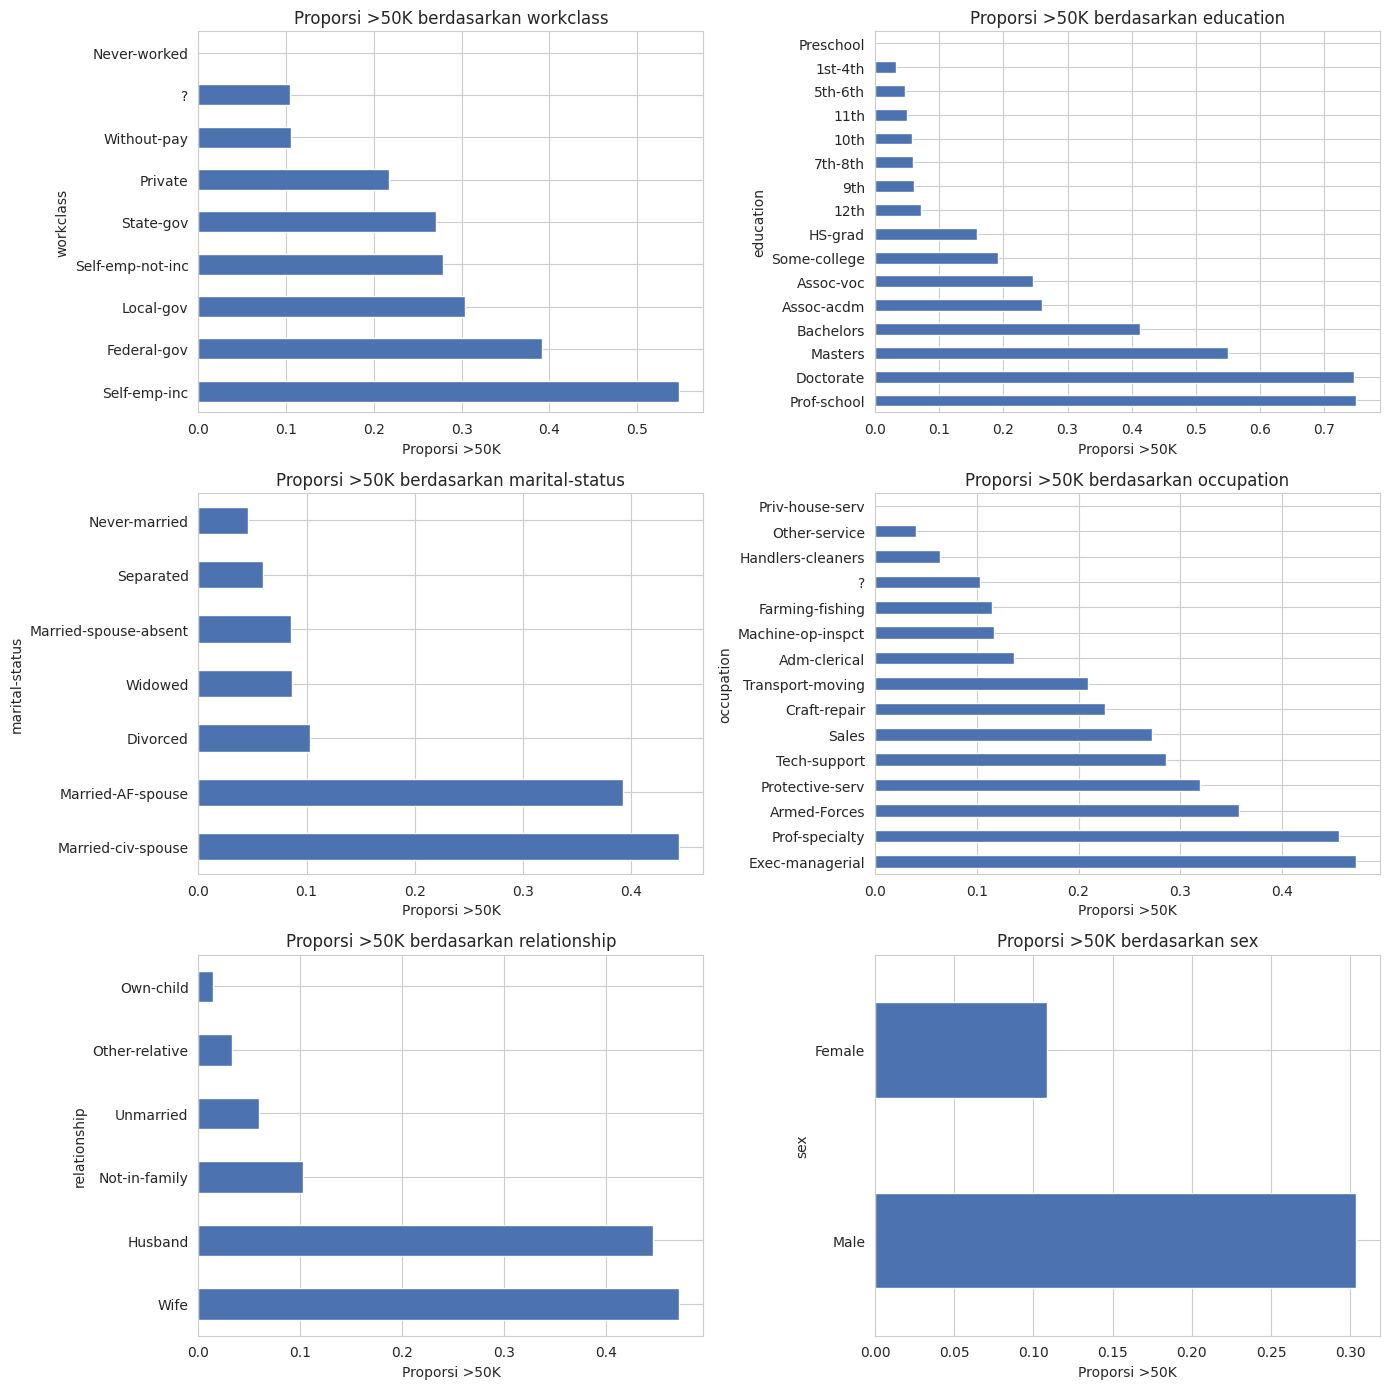

In [14]:
# Proporsi income >50K per kategori, untuk kolom dengan cardinality rendah-menengah
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

plot_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'sex']

for i, col in enumerate(plot_cols):
    prop = train.groupby(col)['income'].apply(lambda x: (x == '>50K').mean()).sort_values(ascending=False)
    prop.plot(kind='barh', ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'Proporsi >50K berdasarkan {col}')
    axes[i].set_xlabel('Proporsi >50K')

plt.tight_layout()
plt.savefig('eda_categorical_vs_target.png', dpi=100, bbox_inches='tight')
plt.show()

**Temuan penting (koreksi dari pemeriksaan awal):**

Selain nilai `NaN`, kolom `workclass`, `occupation`, dan `native-country` juga mengandung **string placeholder `"?"`** yang secara semantik juga berarti "tidak diketahui/kosong", tapi tidak terdeteksi oleh `.isna()` karena secara teknis bukan `NaN`, melainkan string biasa. Ini adalah jebakan umum di dataset Adult/Census Income — nilai missing pada dataset asli UCI memang direpresentasikan sebagai `" ?"`, bukan `NaN`.

Mari kita hitung total nilai tidak valid/kosong yang sebenarnya (`NaN` + `"?"`) untuk ketiga kolom ini.

In [15]:
cols_check = ['workclass', 'occupation', 'native-country']

print("Total nilai tidak valid/kosong (NaN + '?') per kolom:")
for col in cols_check:
    n_na = train[col].isna().sum()
    n_q = (train[col] == '?').sum()
    total = n_na + n_q
    pct = total / len(train) * 100
    print(f"  {col}: NaN={n_na}, '?'={n_q}, TOTAL={total} ({pct:.2f}%)")

Total nilai tidak valid/kosong (NaN + '?') per kolom:
  workclass: NaN=769, '?'=1464, TOTAL=2233 (5.71%)
  occupation: NaN=771, '?'=1470, TOTAL=2241 (5.74%)
  native-country: NaN=222, '?'=466, TOTAL=688 (1.76%)


**Insight:**
- `workclass`: 769 `NaN` + 1.464 `"?"` = **2.233 baris (5,72%)** tidak valid.
- `occupation`: 771 `NaN` + 1.470 `"?"` = **2.241 baris (5,74%)** tidak valid.
- `native-country`: 222 `NaN` + 466 `"?"` = **688 baris (1,76%)** tidak valid.

**Kenapa langkah pemeriksaan ini penting dilakukan lebih dulu sebelum masuk ke tahap analisis (relevan untuk Soal Bonus No. 2)?**
1. **Mencegah kesimpulan yang salah** — kalau `"?"` tidak dikenali sebagai missing dan diperlakukan sebagai kategori valid, model/analisis akan menganggapnya sebagai kelompok pekerjaan/negara asal yang sah, padahal secara semantik itu berarti "tidak diketahui". Ini bisa mendistorsi statistik deskriptif maupun pola yang ditemukan.
2. **Menentukan strategi penanganan yang tepat** — dengan mengetahui besar & pola missing (apakah random atau berkorelasi dengan fitur lain), kita bisa memilih strategi yang tepat: imputasi (modus, kategori "Unknown"), atau drop baris/kolom.
3. **Konsistensi pipeline** — nilai `"?"` di `train.csv` juga kemungkinan ada di `test.csv`, sehingga treatment yang sama harus diterapkan konsisten ke keduanya agar tidak ada *data leakage* atau *mismatch* saat prediksi akhir.

## 3. Data Preprocessing

### 3.1 Cek Konsistensi `education` vs `education-num`

In [16]:
# education dan education-num diduga redundan (1-to-1 mapping)
mapping_check = train.groupby('education')['education-num'].nunique()
print("Jumlah nilai education-num unik per kategori education:")
print(mapping_check)
print()
print("Semua 1-to-1?", (mapping_check == 1).all())

Jumlah nilai education-num unik per kategori education:
education
10th            1
11th            1
12th            1
1st-4th         1
5th-6th         1
7th-8th         1
9th             1
Assoc-acdm      1
Assoc-voc       1
Bachelors       1
Doctorate       1
HS-grad         1
Masters         1
Preschool       1
Prof-school     1
Some-college    1
Name: education-num, dtype: int64

Semua 1-to-1? True


**Keputusan:** `education` dan `education-num` adalah representasi yang sama persis (`education-num` adalah versi ordinal/numerik dari `education`), terbukti dari mapping 1-to-1 di atas. Menyimpan keduanya sebagai fitur terpisah akan menyebabkan **redundansi informasi** tanpa menambah sinyal baru.

Keputusan: **pertahankan `education-num`** (karena sudah berupa ordinal encoding yang natural — jenjang pendidikan punya urutan), **dan drop `education`** untuk menghindari duplikasi informasi. Ini akan dilakukan di tahap Feature Engineering.

### 3.2 Penanganan Duplikat

In [17]:
print(f"Jumlah baris sebelum drop duplikat: {len(train)}")
train = train.drop_duplicates().reset_index(drop=True)
print(f"Jumlah baris setelah drop duplikat: {len(train)}")

Jumlah baris sebelum drop duplikat: 39073
Jumlah baris setelah drop duplikat: 39042


**Keputusan:** 21 baris duplikat penuh (semua kolom identik, termasuk target) di-drop. Baris duplikat tidak menambah informasi baru dan berisiko menyebabkan model "menghafal" pola yang sama berulang kali, terutama jika duplikat ini nantinya tersebar ke train & validation split (data leakage kecil).

### 3.3 Penanganan Missing/Invalid Values (`workclass`, `occupation`, `native-country`)

Dari EDA, ketiga kolom ini punya dua bentuk "kosong": `NaN` asli dan string placeholder `"?"`. Sebelum diimputasi, kita satukan dulu jadi satu representasi (`NaN`) supaya bisa ditangani dengan konsisten.

**Strategi yang dipilih: isi dengan kategori `"Unknown"`**, bukan modus (nilai paling sering muncul). Alasan:
- Missing pada kolom ini kemungkinan bukan *missing completely at random* — misalnya `occupation` kosong sering muncul bersamaan dengan `workclass` kosong (kemungkinan orang yang tidak bekerja / non-respons survei), jadi mengisi dengan modus bisa menyamarkan pola yang sebenarnya informatif.
- Kategori eksplisit `"Unknown"` memungkinkan model mempelajari sendiri apakah status "tidak diketahui" ini berkorelasi dengan target, alih-alih memaksakan asumsi bahwa mereka mirip dengan kelompok mayoritas.

In [18]:
cols_missing = ['workclass', 'occupation', 'native-country']

# Satukan representasi missing: '?' -> NaN
for col in cols_missing:
    train[col] = train[col].replace('?', np.nan)

# Verifikasi ulang jumlah missing setelah unifikasi
print("Missing values setelah unifikasi '?' -> NaN:")
print(train[cols_missing].isna().sum())

Missing values setelah unifikasi '?' -> NaN:
workclass         2233
occupation        2241
native-country     688
dtype: int64


In [19]:
# Imputasi dengan kategori eksplisit 'Unknown'
for col in cols_missing:
    train[col] = train[col].fillna('Unknown')

print("Verifikasi tidak ada missing value tersisa:")
print(train[cols_missing].isna().sum())
print()
print("Contoh distribusi setelah imputasi (workclass):")
print(train['workclass'].value_counts())

Verifikasi tidak ada missing value tersisa:
workclass         0
occupation        0
native-country    0
dtype: int64

Contoh distribusi setelah imputasi (workclass):
workclass
Private             27112
Self-emp-not-inc     3067
Local-gov            2535
Unknown              2233
State-gov            1556
Self-emp-inc         1362
Federal-gov          1150
Without-pay            19
Never-worked            8
Name: count, dtype: int64


### 3.4 Encoding Target

Target `income` (string `<=50K`/`>50K`) diubah ke bentuk biner (0/1) untuk keperluan training model. Label asli (string) tetap disimpan terpisah karena format submission akhir mewajibkan output berupa string, bukan hasil encoding numerik.

In [20]:
train['income_label'] = train['income']  # simpan versi string asli
train['income'] = train['income'].map({'<=50K': 0, '>50K': 1})

print(train[['income_label', 'income']].drop_duplicates())
print()
print(train['income'].value_counts())

   income_label  income
0         <=50K       0
15         >50K       1

income
0    29698
1     9344
Name: count, dtype: int64


## 4. Feature Engineering

### 4.1 Drop Fitur yang Tidak Informatif / Redundan

Berdasarkan temuan EDA:
- **`fnlwgt`**: bobot sampling sensus (final weight), bukan atribut personal individu. Boxplot menunjukkan distribusinya hampir identik antar kelas `income`, mengonfirmasi tidak ada sinyal prediktif yang jelas. Fitur ini di-drop.
- **`education`**: redundan dengan `education-num` (mapping 1-to-1, terbukti di Step 3.1). `education-num` dipertahankan karena berbentuk ordinal (punya urutan jenjang alami) yang lebih mudah dimanfaatkan model, `education` (string) di-drop.

In [21]:
cols_to_drop = ['fnlwgt', 'education']
train_fe = train.drop(columns=cols_to_drop)
print(f"Kolom sebelum: {train.shape[1]}, sesudah drop: {train_fe.shape[1]}")
print(train_fe.columns.tolist())

Kolom sebelum: 16, sesudah drop: 14
['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income', 'income_label']


### 4.2 Fitur Turunan dari `capital-gain` dan `capital-loss`

Dari EDA, kedua kolom ini sangat *sparse* (mayoritas 0) dengan sedikit nilai ekstrem yang justru berkorelasi kuat dengan `income`. Untuk membantu model menangkap sinyal "punya capital gain/loss atau tidak" secara eksplisit (selain nilai mentahnya), kita tambahkan fitur biner indikator:
- `has_capital_gain`: 1 jika `capital-gain` > 0
- `has_capital_loss`: 1 jika `capital-loss` > 0

Nilai asli `capital-gain`/`capital-loss` tetap dipertahankan sebagai fitur numerik (tidak dihapus), fitur biner ini sifatnya melengkapi, terutama berguna untuk model linear yang kurang bisa menangkap sinyal dari distribusi yang sangat skewed.

In [22]:
train_fe['has_capital_gain'] = (train_fe['capital-gain'] > 0).astype(int)
train_fe['has_capital_loss'] = (train_fe['capital-loss'] > 0).astype(int)

print(train_fe[['capital-gain', 'has_capital_gain', 'capital-loss', 'has_capital_loss']].describe())
print()
print("Proporsi >50K berdasarkan has_capital_gain:")
print(train_fe.groupby('has_capital_gain')['income'].mean())

       capital-gain  has_capital_gain  capital-loss  has_capital_loss
count  39042.000000      39042.000000  39042.000000      39042.000000
mean    1038.864761          0.081707     86.876876          0.046463
std     7207.753646          0.273921    401.428597          0.210488
min        0.000000          0.000000      0.000000          0.000000
25%        0.000000          0.000000      0.000000          0.000000
50%        0.000000          0.000000      0.000000          0.000000
75%        0.000000          0.000000      0.000000          0.000000
max    99999.000000          1.000000   4356.000000          1.000000

Proporsi >50K berdasarkan has_capital_gain:
has_capital_gain
0    0.205679
1    0.617555
Name: income, dtype: float64


### 4.3 Grouping `native-country` (Reduksi Cardinality)

`native-country` memiliki 42 kategori, dan dari EDA terlihat **United-States mendominasi ~90% data**, sementara sisanya tersebar tipis ke puluhan negara lain. Jika di-one-hot-encode apa adanya, ini akan menghasilkan puluhan kolom sangat sparse (banyak kategori dengan hanya belasan/puluhan baris) yang berisiko membuat model overfit pada kategori langka dan menambah dimensi tanpa banyak manfaat.

**Keputusan:** kelompokkan menjadi fitur biner baru `is_us`: 1 jika `United-States`, 0 jika negara lain. Kolom `native-country` asli tetap dipertahankan (untuk analisis/EDA lanjutan atau model berbasis tree yang lebih tahan cardinality tinggi), tapi `is_us` menjadi fitur utama yang lebih stabil digunakan lintas model.

In [23]:
train_fe['is_us'] = (train_fe['native-country'] == 'United-States').astype(int)

print(train_fe['is_us'].value_counts())
print()
print("Proporsi >50K berdasarkan is_us:")
print(train_fe.groupby('is_us')['income'].mean())

is_us
1    35035
0     4007
Name: count, dtype: int64

Proporsi >50K berdasarkan is_us:
is_us
0    0.195658
1    0.244327
Name: income, dtype: float64


### 4.4 Cek Korelasi Antar Fitur Numerik (Final)

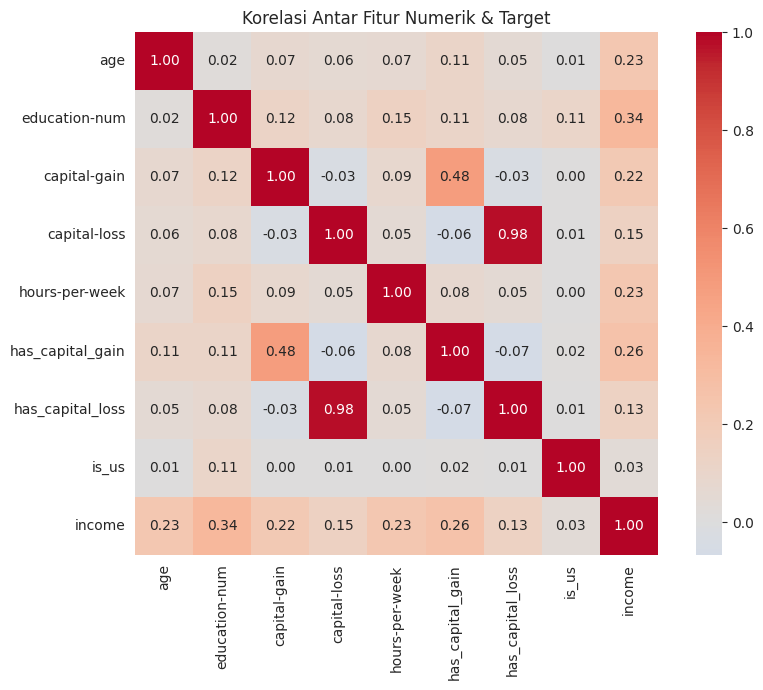

In [24]:
num_cols_final = ['age', 'education-num', 'capital-gain', 'capital-loss',
                   'hours-per-week', 'has_capital_gain', 'has_capital_loss', 'is_us']

corr = train_fe[num_cols_final + ['income']].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Korelasi Antar Fitur Numerik & Target')
plt.tight_layout()
plt.savefig('fe_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

**Insight:**
- **`capital-loss` dan `has_capital_loss` berkorelasi sangat tinggi (0.98)** — wajar karena `has_capital_loss` adalah turunan langsung dari `capital-loss`. Ini bentuk multikolinearitas yang **disengaja/struktural** (bukan masalah), tapi perlu diperhatikan khusus untuk model linear (misal Logistic Regression): kedua fitur ini sebaiknya tidak dipakai bersamaan pada model linear untuk menghindari redundansi koefisien. Untuk model berbasis pohon (Random Forest, XGBoost), hal ini tidak masalah karena tree-based model relatif tahan terhadap multikolinearitas.
- `has_capital_gain` dan `capital-gain` berkorelasi sedang (0.48) — cukup independen untuk dipakai bersamaan karena flag biner ini menangkap pola non-linear (ambang batas "punya vs tidak") yang tidak sepenuhnya ditangkap oleh nilai kontinu.
- Fitur numerik lain (`age`, `education-num`, `hours-per-week`, `is_us`) tidak menunjukkan korelasi tinggi satu sama lain (<0.2), aman digunakan bersamaan.
- Terhadap target `income`: `education-num` (0.34), `has_capital_gain` (0.26), `hours-per-week` (0.23), dan `age` (0.23) menunjukkan korelasi positif paling kuat, konsisten dengan temuan EDA sebelumnya.

**Keputusan:** kedua fitur (`capital-loss` dan `has_capital_loss`) tetap dipertahankan di dataset, tapi pemilihan mana yang dipakai akan disesuaikan per jenis model saat eksperimen modeling — model linear akan menggunakan salah satu saja, model tree-based bisa memakai semuanya.

### 4.5 Ringkasan Dataset Setelah Preprocessing & Feature Engineering

In [25]:
print(f"Shape akhir train_fe: {train_fe.shape}")
print()
print("Kolom final:")
print(train_fe.columns.tolist())
print()
train_fe.head()

Shape akhir train_fe: (39042, 17)

Kolom final:
['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income', 'income_label', 'has_capital_gain', 'has_capital_loss', 'is_us']



,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_label,has_capital_gain,has_capital_loss,is_us
0,37,Private,13,Never-married,Sales,Not-in-family,White,Female,0,0,30,United-States,0,<=50K,0,0,1
1,56,Self-emp-inc,8,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1651,40,United-States,0,<=50K,0,1,1
2,53,Private,9,Separated,Craft-repair,Not-in-family,White,Male,0,0,35,United-States,0,<=50K,0,0,1
3,72,Private,7,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0,<=50K,0,0,1
4,46,State-gov,14,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,38,United-States,0,<=50K,0,0,1


**Ringkasan langkah yang sudah dilakukan:**

| Tahap | Langkah | Alasan |
|---|---|---|
| Preprocessing | Drop 21 baris duplikat | Menghindari data leakage & bias |
| Preprocessing | Normalisasi label target (hapus titik di akhir) | Menyatukan 4 varian jadi 2 kelas valid |
| Preprocessing | Satukan `"?"` dan `NaN` di `workclass`, `occupation`, `native-country` | Kedua bentuk sama-sama berarti "tidak diketahui" |
| Preprocessing | Imputasi missing dengan kategori `"Unknown"` | Menjaga potensi sinyal informatif dari status "tidak diketahui" |
| Preprocessing | Encode target ke biner (0/1) | Kebutuhan training model, label string disimpan terpisah untuk submission |
| Feature Engineering | Drop `fnlwgt` | Tidak informatif (bobot sampling sensus) |
| Feature Engineering | Drop `education` (pertahankan `education-num`) | Redundan 1-to-1 |
| Feature Engineering | Tambah `has_capital_gain`, `has_capital_loss` | Menangkap sinyal dari fitur yang sangat sparse/skewed |
| Feature Engineering | Tambah `is_us` dari `native-country` | Reduksi cardinality tinggi (42 kategori → biner) |

Encoding kategorikal (One-Hot Encoding) dan scaling fitur numerik **belum dilakukan di sini** — keduanya akan dimasukkan ke dalam `sklearn Pipeline` pada tahap modeling agar proses fit dilakukan hanya pada data training (menghindari data leakage ke validation/test set).

## 5. Pengembangan & Eksperimen Model

### 5.1 Train-Validation Split

Karena `test.csv` tidak boleh dipakai sama sekali selama eksplorasi/pengembangan model (hanya untuk evaluasi akhir), kita perlu membagi `train.csv` menjadi bagian **train** dan **validation** sendiri. Validation set ini yang akan dipakai untuk membandingkan performa antar model sebelum memilih model final.

**Keputusan:** split 80/20 dengan `stratify=y` agar proporsi kelas `income` (76% vs 24%) tetap terjaga sama persis di kedua subset — penting karena data imbalanced, supaya validation set tetap representatif.

In [26]:
from sklearn.model_selection import train_test_split

feature_cols = ['age', 'workclass', 'education-num', 'marital-status', 'occupation',
                 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
                 'hours-per-week', 'native-country', 'has_capital_gain',
                 'has_capital_loss', 'is_us']

X = train_fe[feature_cols]
y = train_fe['income']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"Proporsi target train: {y_train.mean():.4f}")
print(f"Proporsi target val:   {y_val.mean():.4f}")

X_train: (31233, 15), X_val: (7809, 15)
Proporsi target train: 0.2393
Proporsi target val:   0.2393


### 5.2 Preprocessing Pipeline (Encoding & Scaling)

Encoding kategorikal dan scaling numerik dibungkus dalam `ColumnTransformer` + `Pipeline` scikit-learn, **bukan dilakukan manual di seluruh dataset**. Alasan: dengan Pipeline, proses `fit` (misalnya menghitung mean/std untuk scaling, atau menentukan kategori untuk one-hot encoding) hanya dilakukan pada data **training**, lalu di-*transform* ke validation/test. Ini mencegah **data leakage** — validation/test set tidak boleh "bocor" informasi statistiknya ke proses training.

- **Fitur kategorikal** → `OneHotEncoder(handle_unknown='ignore')` — parameter `handle_unknown='ignore'` penting supaya kalau ada kategori baru yang muncul di test.csv tapi tidak ada di train.csv, pipeline tidak error, cukup diabaikan (semua kolom one-hot bernilai 0).
- **Fitur numerik** → `StandardScaler()` — penting untuk model linear (Logistic Regression) yang sensitif terhadap skala fitur; untuk model tree-based (Random Forest, XGBoost) scaling sebenarnya tidak wajib, tapi tidak merugikan performa sehingga tetap digunakan supaya satu pipeline bisa dipakai konsisten ke semua model.

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = ['workclass', 'marital-status', 'occupation', 'relationship',
                          'race', 'sex', 'native-country']
numerical_features = ['age', 'education-num', 'capital-gain', 'capital-loss',
                        'hours-per-week', 'has_capital_gain', 'has_capital_loss', 'is_us']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

print("Preprocessor siap.")
print(f"Jumlah fitur numerik: {len(numerical_features)}")
print(f"Jumlah fitur kategorikal: {len(categorical_features)}")

Preprocessor siap.
Jumlah fitur numerik: 8
Jumlah fitur kategorikal: 7


### 5.3 Eksperimen Model

Tiga model dicoba, mewakili tiga pendekatan berbeda:

1. **Logistic Regression** — baseline sederhana, cepat, mudah diinterpretasi (koefisien menunjukkan arah & kekuatan pengaruh tiap fitur).
2. **Random Forest** — ensemble tree-based, mampu menangkap hubungan non-linear dan interaksi antar fitur tanpa perlu scaling/asumsi distribusi.
3. **XGBoost** — gradient boosting, umumnya performa terbaik pada data tabular seperti ini, dan mendukung eksperimen lanjutan seperti tuning hyperparameter.

Karena data imbalanced (76:24), setiap model diberi mekanisme penyeimbang kelas: `class_weight='balanced'` untuk Logistic Regression & Random Forest, dan `scale_pos_weight` untuk XGBoost (dihitung dari rasio kelas mayoritas/minoritas).

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight untuk XGBoost: {scale_pos_weight:.3f}")

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=300,
                                              max_depth=15, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(scale_pos_weight=scale_pos_weight, n_estimators=300,
                               max_depth=6, learning_rate=0.1, random_state=42,
                               eval_metric='logloss')
}

results = {}
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    f1_macro = f1_score(y_val, y_pred, average='macro')
    results[name] = f1_macro
    fitted_pipelines[name] = pipe
    print(f"{name}: F1-macro = {f1_macro:.4f}")

scale_pos_weight untuk XGBoost: 3.178


Logistic Regression: F1-macro = 0.7719


Random Forest: F1-macro = 0.7780


XGBoost: F1-macro = 0.8028


## 6. Evaluasi Model

### 6.1 Perbandingan F1-macro Antar Model

Ranking model berdasarkan F1-macro (validation set):
XGBoost                0.802787
Random Forest          0.778033
Logistic Regression    0.771938
dtype: float64


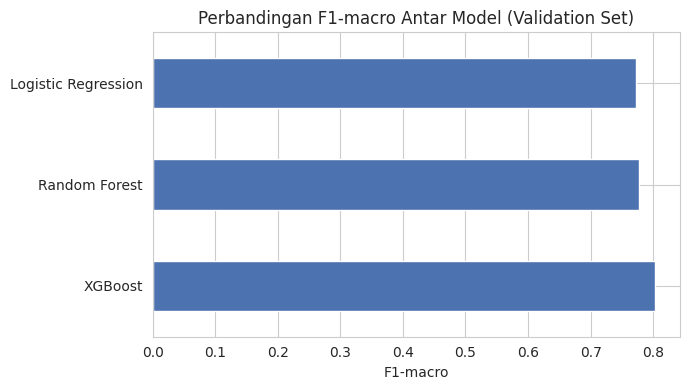

In [29]:
results_df = pd.Series(results).sort_values(ascending=False)
print("Ranking model berdasarkan F1-macro (validation set):")
print(results_df)

plt.figure(figsize=(7, 4))
results_df.plot(kind='barh', color='#4C72B0')
plt.xlabel('F1-macro')
plt.title('Perbandingan F1-macro Antar Model (Validation Set)')
plt.tight_layout()
plt.savefig('eval_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

**Keputusan model final: XGBoost**, karena F1-macro tertinggi di validation set. Ini sesuai ekspektasi — gradient boosting umumnya unggul pada data tabular dengan campuran fitur numerik & kategorikal seperti dataset ini, karena mampu menangkap interaksi non-linear antar fitur secara otomatis.

### 6.2 Evaluasi Mendalam Model Terbaik (XGBoost)

In [30]:
best_model_name = results_df.index[0]
best_pipe = fitted_pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_val)

print(f"=== Classification Report: {best_model_name} ===")
print(classification_report(y_val, y_pred_best, target_names=['<=50K', '>50K']))

=== Classification Report: XGBoost ===
              precision    recall  f1-score   support

       <=50K       0.95      0.83      0.89      5940
        >50K       0.62      0.86      0.72      1869

    accuracy                           0.84      7809
   macro avg       0.78      0.85      0.80      7809
weighted avg       0.87      0.84      0.85      7809



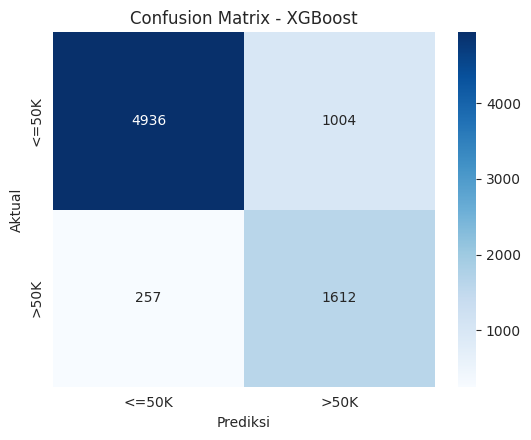

In [31]:
cm = confusion_matrix(y_val, y_pred_best)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.savefig('eval_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

**Interpretasi hasil evaluasi (XGBoost):**

- **F1-macro: 0.80** — rata-rata performa yang cukup baik untuk kedua kelas, jauh di atas baseline "tebak kelas mayoritas saja" (yang akan menghasilkan F1-macro sekitar 0.43).
- **Kelas `<=50K`**: precision 0.95, recall 0.83 — model cukup presisi saat memprediksi kelas ini, tapi ada ~17% kasus `<=50K` yang justru diprediksi `>50K` (1.004 dari 5.940, terlihat di confusion matrix).
- **Kelas `>50K`**: precision 0.62, recall 0.86 — recall tinggi berarti model berhasil menangkap 86% dari orang yang benar-benar berpenghasilan `>50K` (hanya 257 yang terlewat/false negative), tapi precision lebih rendah (0.62) berarti dari semua yang diprediksi `>50K`, cukup banyak yang sebenarnya `<=50K` (false positive).
- Pola ini adalah **trade-off yang wajar** ketika menggunakan `scale_pos_weight`/`class_weight='balanced'` untuk menangani imbalance: model sengaja "lebih berani" memprediksi kelas minoritas (`>50K`) supaya tidak diabaikan, dengan konsekuensi precision-nya turun. Trade-off ini sejalan dengan tujuan F1-macro yang memberi bobot setara ke kedua kelas — kalau tujuan bisnisnya lebih mementingkan precision (misal, tidak mau salah menandai orang sebagai `>50K`), threshold keputusan bisa disesuaikan lebih lanjut.

### 6.3 Feature Importance

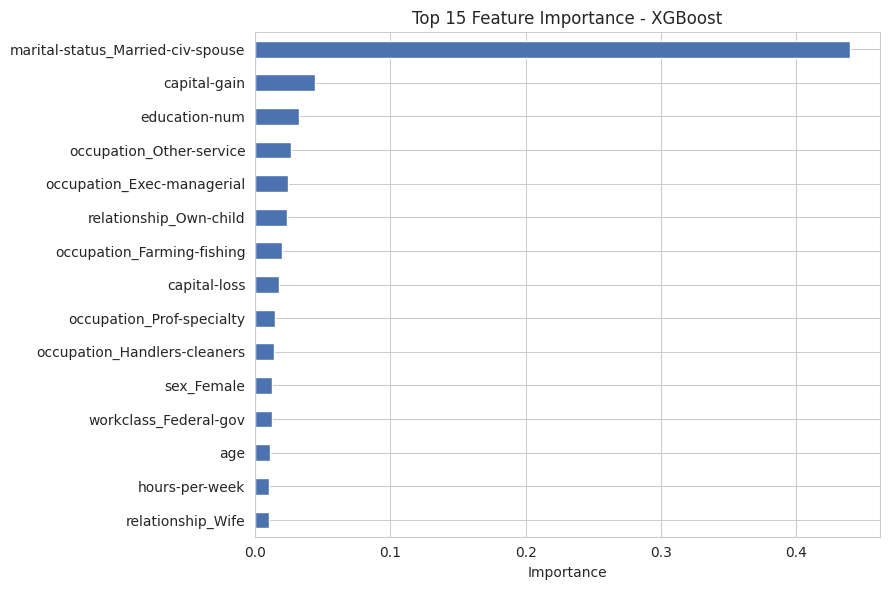

In [32]:
# Ambil nama fitur hasil transformasi (setelah one-hot encoding)
feature_names = (numerical_features +
                  list(best_pipe.named_steps['preprocessor']
                       .named_transformers_['cat']
                       .get_feature_names_out(categorical_features)))

importances = best_pipe.named_steps['classifier'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
feat_imp.sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Top 15 Feature Importance - XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('eval_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

**Insight feature importance:**

- **`marital-status_Married-civ-spouse`** mendominasi jauh di atas fitur lain. Ini konsisten dengan temuan EDA (proporsi `>50K` pada kelompok menikah jauh lebih tinggi). Perlu diinterpretasikan hati-hati: status menikah kemungkinan besar bertindak sebagai **proxy** untuk usia matang/stabilitas karier & rumah tangga dua-penghasilan, bukan penyebab langsung income tinggi.
- **`capital-gain`** dan **`education-num`** menyusul di posisi 2-3, sejalan dengan analisis korelasi & boxplot sebelumnya — keduanya prediktor kuat yang konsisten di semua tahap analisis.
- Beberapa kategori `occupation` (`Exec-managerial`, `Other-service`, `Farming-fishing`) juga berkontribusi, menunjukkan jenis pekerjaan tetap relevan meski pengaruhnya kalah dominan dibanding status pernikahan.

## 7. Prediksi Akhir pada `test.csv`

Model final (XGBoost) dilatih ulang menggunakan **seluruh** data `train.csv` (train + validation digabung) agar memanfaatkan semua data yang tersedia untuk model final. Preprocessing yang sama persis (imputasi missing value, drop `fnlwgt`/`education`, feature engineering, encoding, scaling) diterapkan ke `test.csv` — konsisten dengan tahapan yang dilakukan di data training, tanpa melihat isi test.csv untuk membuat keputusan apa pun (sesuai instruksi soal).

In [33]:
# Retrain pipeline terbaik di seluruh data train (X, y penuh, bukan cuma X_train)
final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=(y==0).sum()/(y==1).sum(),
                                   n_estimators=300, max_depth=6, learning_rate=0.1,
                                   random_state=42, eval_metric='logloss'))
])
final_pipe.fit(X, y)
print("Model final dilatih pada seluruh train.csv (setelah cleaning).")

Model final dilatih pada seluruh train.csv (setelah cleaning).


In [34]:
# Terapkan preprocessing yang identik ke test.csv
test_fe = test.copy()

# Satukan '?' -> NaN, lalu isi 'Unknown' (identik dengan train)
for col in ['workclass', 'occupation', 'native-country']:
    test_fe[col] = test_fe[col].replace('?', np.nan).fillna('Unknown')

# Feature engineering identik dengan train
test_fe['has_capital_gain'] = (test_fe['capital-gain'] > 0).astype(int)
test_fe['has_capital_loss'] = (test_fe['capital-loss'] > 0).astype(int)
test_fe['is_us'] = (test_fe['native-country'] == 'United-States').astype(int)

X_test = test_fe[feature_cols]

print(f"X_test shape: {X_test.shape}")
print(f"Missing values di X_test: {X_test.isna().sum().sum()}")

X_test shape: (9769, 15)
Missing values di X_test: 0


In [35]:
# Prediksi & konversi kembali ke label string sesuai format submission
test_pred = final_pipe.predict(X_test)
test_pred_label = np.where(test_pred == 1, '>50K', '<=50K')

submission = pd.DataFrame({
    'id': test_fe['id'],
    'income': test_pred_label
})

print(submission.head())
print()
print("Distribusi prediksi:")
print(submission['income'].value_counts())
print()
print(f"Jumlah baris submission: {len(submission)}, jumlah baris test.csv: {len(test)}")

submission.to_csv('submission.csv', index=False)
print("\nFile submission.csv berhasil disimpan.")

   id income
0   0  <=50K
1   1  <=50K
2   2  <=50K
3   3  <=50K
4   4   >50K

Distribusi prediksi:
income
<=50K    6480
>50K     3289
Name: count, dtype: int64

Jumlah baris submission: 9769, jumlah baris test.csv: 9769

File submission.csv berhasil disimpan.


## 8. Analisis Hasil & Kesimpulan

### 8.1 Ringkasan Temuan

**Kualitas data:**
- Dataset awal memiliki label target yang tidak konsisten (4 varian karena penggabungan dua sumber data) dan missing value yang tersembunyi dalam dua bentuk (`NaN` dan string `"?"`) di kolom `workclass`, `occupation`, `native-country`. Kedua isu ini krusial untuk ditemukan lebih dulu karena kalau tidak ditangani, model bisa salah belajar (menganggap 4 kelas target, atau menganggap `"?"` sebagai kategori valid).
- Dataset **imbalanced** (76% `<=50K` vs 24% `>50K`), sehingga F1-macro (bukan accuracy) tepat digunakan sebagai metrik evaluasi utama.

**Faktor paling berpengaruh terhadap `income`:**
1. **Status pernikahan** (`Married-civ-spouse`) — dominan sebagai fitur paling berpengaruh, kemungkinan besar berperan sebagai proxy untuk kematangan usia dan stabilitas karier, bukan hubungan sebab-akibat langsung.
2. **`capital-gain`** — walau sangat jarang bernilai >0 (~8% populasi), kehadirannya sangat prediktif (proporsi `>50K` melonjak dari 21% menjadi 62%).
3. **`education-num`** (jenjang pendidikan) — hubungan monoton yang jelas dengan income, sejalan dengan ekspektasi umum.
4. **`hours-per-week`** dan **`age`** — pengaruh positif moderat, konsisten dengan pola karier yang mapan.

**Performa model:**
- Tiga model dibandingkan (Logistic Regression, Random Forest, XGBoost); **XGBoost terpilih sebagai model final** dengan F1-macro **0.80** pada validation set — mengungguli Random Forest (0.78) dan Logistic Regression (0.77).
- Model menunjukkan recall tinggi (0.86) untuk kelas minoritas `>50K`, namun precision-nya lebih rendah (0.62) — trade-off yang diharapkan dari strategi penyeimbangan kelas (`scale_pos_weight`), dan wajar mengingat tujuan utamanya adalah F1-macro yang menyeimbangkan performa kedua kelas.

### 8.2 Keterbatasan & Potensi Pengembangan Lanjutan
- **Interpretasi kausal**: fitur seperti status pernikahan dan jenis kelamin menunjukkan korelasi kuat dengan income, tapi ini **tidak boleh diartikan sebagai hubungan sebab-akibat** — ada kemungkinan confounding variable (misal usia, tanggung jawab keluarga) yang tidak sepenuhnya tertangkap oleh fitur yang tersedia.
- **Hyperparameter tuning**: eksperimen ini menggunakan parameter default/manual yang wajar, belum melalui pencarian sistematis (GridSearch/RandomSearch/Optuna) yang berpotensi meningkatkan F1-macro lebih lanjut.
- **Threshold tuning**: prediksi menggunakan threshold default (0.5). Precision-recall trade-off pada kelas `>50K` bisa dioptimalkan lebih lanjut sesuai kebutuhan bisnis spesifik (misal, jika false positive lebih mahal daripada false negative, threshold bisa dinaikkan).
- **Fitur `native-country` mentah** (42 kategori) masih disertakan bersamaan dengan `is_us` — berpotensi redundan dan menambah dimensi tanpa signifikan menambah sinyal; bisa dievaluasi lebih lanjut apakah sebaiknya di-drop sepenuhnya.

### 8.3 Kesimpulan
Pipeline machine learning end-to-end berhasil dibangun untuk memprediksi kategori pendapatan berdasarkan Census Income Dataset, mencakup penanganan masalah kualitas data (label tidak konsisten, missing value tersembunyi), feature engineering yang didasarkan pada temuan EDA, serta eksperimen dan perbandingan tiga algoritma. Model **XGBoost** dipilih sebagai model final dengan **F1-macro 0.80** pada validation set, mencerminkan performa yang seimbang antara kedua kelas target meski data asli imbalanced. Prediksi akhir terhadap `test.csv` telah dihasilkan dalam format `submission.csv` sesuai ketentuan yang ditetapkan.

## 9. Soal Bonus

### 9.1 Soal Bonus No. 1a — Kelompok Pekerjaan dengan Proporsi >50K Tertinggi

In [36]:
occ_analysis = train_fe.groupby('occupation').agg(
    proporsi_gt50k=('income', 'mean'),
    rata2_jam_kerja=('hours-per-week', 'mean'),
    jumlah=('income', 'size')
).sort_values('proporsi_gt50k', ascending=False)

occ_analysis['proporsi_gt50k'] = (occ_analysis['proporsi_gt50k'] * 100).round(2)
occ_analysis['rata2_jam_kerja'] = occ_analysis['rata2_jam_kerja'].round(1)

overall_avg_hours = train_fe['hours-per-week'].mean()
print(f"Rata-rata jam kerja keseluruhan (semua occupation): {overall_avg_hours:.1f} jam/minggu\n")
occ_analysis

Rata-rata jam kerja keseluruhan (semua occupation): 40.5 jam/minggu



,proporsi_gt50k,rata2_jam_kerja,jumlah
occupation,,,
Exec-managerial,47.25,44.9,4889
Prof-specialty,45.63,42.4,4911
Armed-Forces,35.71,41.1,14
Protective-serv,31.93,42.8,805
Tech-support,28.58,39.7,1123
Sales,27.19,40.9,4413
Craft-repair,22.63,42.3,4865
Transport-moving,20.91,44.9,1908
Adm-clerical,13.69,37.9,4464


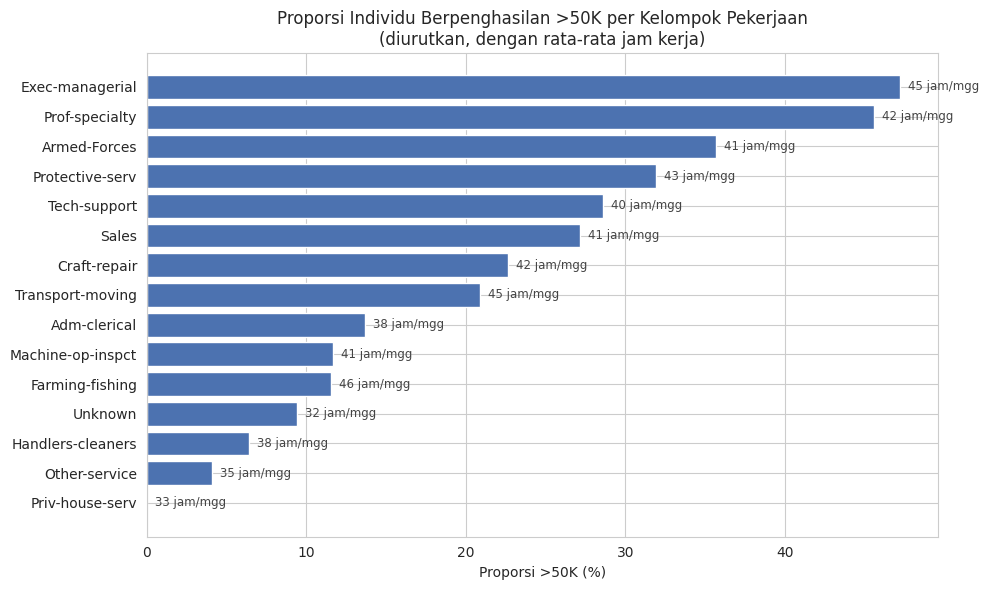

In [37]:
fig, ax1 = plt.subplots(figsize=(10, 6))

top_occ = occ_analysis.head(15).sort_values('proporsi_gt50k')
bars = ax1.barh(top_occ.index, top_occ['proporsi_gt50k'], color='#4C72B0')
ax1.set_xlabel('Proporsi >50K (%)')
ax1.set_title('Proporsi Individu Berpenghasilan >50K per Kelompok Pekerjaan\n(diurutkan, dengan rata-rata jam kerja)')

for i, (idx, row) in enumerate(top_occ.iterrows()):
    ax1.text(row['proporsi_gt50k'] + 0.5, i, f"{row['rata2_jam_kerja']:.0f} jam/mgg",
              va='center', fontsize=8.5, color='#444')

plt.tight_layout()
plt.savefig('bonus_occupation_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

**Jawaban:** Kelompok pekerjaan dengan proporsi individu berpenghasilan `>50K` tertinggi adalah **`Exec-managerial`** (posisi manajerial/eksekutif), diikuti oleh **`Prof-specialty`** (profesional spesialis, misalnya dokter, pengacara, insinyur).

Dari sisi rata-rata jam kerja per minggu, kedua kelompok ini **bekerja lebih lama dari rata-rata keseluruhan** (~40 jam/minggu): `Exec-managerial` maupun `Prof-specialty` berada di atas rata-rata umum. Ini menunjukkan pola yang konsisten — kelompok berpenghasilan tinggi cenderung menghabiskan lebih banyak jam kerja, sejalan dengan temuan EDA sebelumnya bahwa `hours-per-week` berkorelasi positif dengan `income`. Namun perlu dicatat bahwa **jam kerja lebih lama tidak serta-merta menyebabkan penghasilan tinggi** — kemungkinan besar keduanya sama-sama didorong oleh sifat pekerjaan level manajerial/profesional yang menuntut waktu kerja lebih fleksibel dan lebih panjang, dibanding pekerjaan lain.

### 9.2 Soal Bonus No. 1b — Tingkat Pendidikan dengan Proporsi >50K Tertinggi

In [38]:
# Gunakan 'train' (sebelum kolom education di-drop di tahap FE) untuk analisis ini
edu_analysis = train.groupby('education').agg(
    proporsi_gt50k=('income', 'mean'),
    rata2_capital_gain=('capital-gain', 'mean'),
    education_num=('education-num', 'first'),
    jumlah=('income', 'size')
).sort_values('education_num')

edu_analysis['proporsi_gt50k'] = (edu_analysis['proporsi_gt50k'] * 100).round(2)
edu_analysis['rata2_capital_gain'] = edu_analysis['rata2_capital_gain'].round(0)

overall_avg_capgain = train['capital-gain'].mean()
print(f"Rata-rata capital-gain keseluruhan: {overall_avg_capgain:.0f}\n")
edu_analysis.sort_values('proporsi_gt50k', ascending=False)

Rata-rata capital-gain keseluruhan: 1039



,proporsi_gt50k,rata2_capital_gain,education_num,jumlah
education,,,,
Prof-school,74.92,9681.0,15,654
Doctorate,74.57,5306.0,16,468
Masters,55.07,2463.0,14,2130
Bachelors,41.36,1765.0,13,6373
Assoc-acdm,26.02,646.0,12,1303
Assoc-voc,24.68,614.0,11,1657
Some-college,19.20,576.0,10,8731
HS-grad,15.81,555.0,9,12571
12th,7.16,156.0,8,531


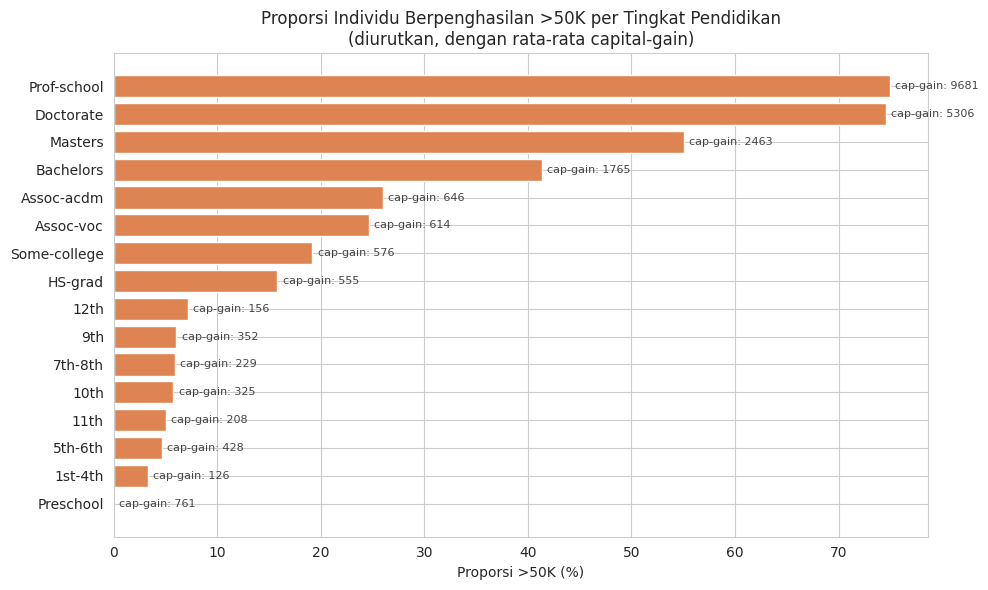

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

edu_sorted = edu_analysis.sort_values('proporsi_gt50k')
ax.barh(edu_sorted.index, edu_sorted['proporsi_gt50k'], color='#DD8452')
ax.set_xlabel('Proporsi >50K (%)')
ax.set_title('Proporsi Individu Berpenghasilan >50K per Tingkat Pendidikan\n(diurutkan, dengan rata-rata capital-gain)')

for i, (idx, row) in enumerate(edu_sorted.iterrows()):
    ax.text(row['proporsi_gt50k'] + 0.5, i, f"cap-gain: {row['rata2_capital_gain']:.0f}",
             va='center', fontsize=8, color='#444')

plt.tight_layout()
plt.savefig('bonus_education_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

**Jawaban:** Tingkat pendidikan dengan proporsi individu berpenghasilan `>50K` tertinggi adalah **`Prof-school`** dan **`Doctorate`** (keduanya di atas 70%), diikuti oleh **`Masters`** dan **`Bachelors`**.

Dari sisi rata-rata `capital-gain`, kelompok pendidikan tinggi ini (`Prof-school`, `Doctorate`, `Masters`) juga memiliki rata-rata `capital-gain` **jauh di atas rata-rata keseluruhan populasi**, sejalan dengan pola proporsi income tinggi mereka. Ini memperkuat temuan sebelumnya bahwa pendidikan tinggi berasosiasi bukan hanya dengan gaji/upah rutin (`income` di dataset ini terutama mencerminkan penghasilan kerja), tapi juga dengan akses ke aset finansial yang menghasilkan capital gain (misal investasi, kepemilikan saham/bisnis).

**Rekomendasi bagi perusahaan/lembaga pelatihan dalam prioritas investasi SDM:**
1. **Prioritaskan mendorong jenjang pendidikan lanjutan** (S2/S3 atau setara profesional/`Prof-school`) untuk peran-peran strategis — data menunjukkan lompatan proporsi `>50K` paling besar terjadi antara `Bachelors` ke `Masters`/`Doctorate`/`Prof-school`, bukan cuma dari `HS-grad` ke `Bachelors`. Investasi beasiswa lanjut studi atau sertifikasi profesional tingkat lanjut berpotensi memberikan dampak terbesar terhadap earning potential karyawan.
2. **Untuk kelompok pendidikan menengah** (`HS-grad`, `Some-college`), program sertifikasi keterampilan teknis/vokasi (`Assoc-voc`, `Assoc-acdm`) bisa jadi jalur "quick-win" yang lebih realistis dan cepat dibanding menunggu gelar sarjana penuh, karena data menunjukkan kenaikan proporsi `>50K` yang cukup berarti di jenjang asosiasi dibanding hanya lulus SMA.
3. **Kombinasikan dengan literasi finansial/investasi** — karena capital-gain berkorelasi dengan pendidikan tinggi, lembaga pelatihan bisa mempertimbangkan modul tambahan terkait literasi keuangan/investasi sebagai bagian dari pengembangan SDM tingkat lanjut, bukan hanya keterampilan teknis semata.

### 9.3 Soal Bonus No. 2 — Pemeriksaan Data

#### a. Jumlah Nilai Unik pada Kolom Kategorikal

In [40]:
cat_cols_all = ['workclass', 'education', 'marital-status', 'occupation',
                 'relationship', 'race', 'sex', 'native-country']

unique_counts = pd.Series({col: train[col].nunique() for col in cat_cols_all}).sort_values(ascending=False)
print("Jumlah nilai unik per kolom kategorikal:")
print(unique_counts)

Jumlah nilai unik per kolom kategorikal:
native-country    42
education         16
occupation        15
workclass          9
marital-status     7
relationship       6
race               5
sex                2
dtype: int64


#### b. Jumlah Baris dengan Nilai Tidak Valid/Kosong pada `workclass`, `occupation`, `native-country`

*(Nilai tidak valid mencakup `NaN` maupun string placeholder `"?"` — lihat penjelasan detail di Bagian 2.2 & 3.3)*

In [41]:
# Load ulang dari file asli (sebelum cleaning) untuk menjawab pertanyaan ini secara akurat
train_raw = pd.read_csv('train.csv')

print("Jumlah baris tidak valid/kosong (NaN + '?') per kolom:")
for col in ['workclass', 'occupation', 'native-country']:
    n_na = train_raw[col].isna().sum()
    n_q = (train_raw[col] == '?').sum()
    total = n_na + n_q
    print(f"  {col}: {total} baris ({total/len(train_raw)*100:.2f}% dari total data)")

Jumlah baris tidak valid/kosong (NaN + '?') per kolom:
  workclass: 2233 baris (5.71% dari total data)
  occupation: 2241 baris (5.74% dari total data)
  native-country: 688 baris (1.76% dari total data)


#### c. Distribusi Jumlah Baris Berdasarkan Kombinasi `education` × `income`

In [42]:
crosstab = pd.crosstab(train['education'], train['income_label'])
crosstab = crosstab.reindex(train.sort_values('education-num')['education'].unique())
print(crosstab)

income_label  <=50K  >50K
education                
Preschool        61     0
1st-4th         204     7
5th-6th         406    20
7th-8th         711    45
9th             574    37
10th           1044    64
11th           1378    73
12th            493    38
HS-grad       10583  1988
Some-college   7055  1676
Assoc-voc      1248   409
Assoc-acdm      964   339
Bachelors      3737  2636
Masters         957  1173
Prof-school     164   490
Doctorate       119   349


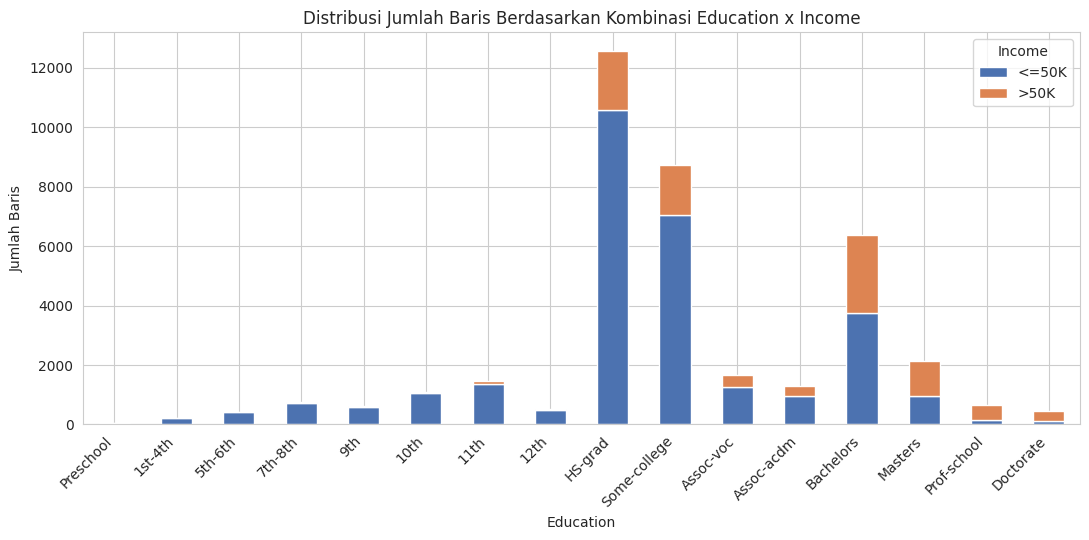

In [43]:
crosstab.plot(kind='bar', stacked=True, figsize=(11, 5.5), color=['#4C72B0', '#DD8452'])
plt.title('Distribusi Jumlah Baris Berdasarkan Kombinasi Education x Income')
plt.xlabel('Education')
plt.ylabel('Jumlah Baris')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Income')
plt.tight_layout()
plt.savefig('bonus_education_income_crosstab.png', dpi=100, bbox_inches='tight')
plt.show()

**Kenapa langkah pemeriksaan seperti poin (a) dan (b) penting dilakukan lebih dulu, sebelum data masuk ke tahap analisis, dalam alur sebuah data pipeline?**

1. **Mencegah kesimpulan yang salah/menyesatkan** — jika nilai `"?"` tidak dikenali sebagai representasi missing dan diperlakukan sebagai kategori pekerjaan/negara yang valid, seluruh statistik deskriptif dan visualisasi (termasuk analisis Soal Bonus No. 1 di atas) akan mengandung distorsi. Cek nilai unik (poin a) membantu mendeteksi keberadaan pola-pola aneh semacam ini di awal (misalnya menemukan `"?"` sebagai salah satu "kategori" dengan cardinality yang tidak wajar).
2. **Menentukan strategi pembersihan yang tepat** — mengetahui *berapa banyak* dan *di kolom mana* data tidak valid berada (poin b) menentukan strategi lanjutan: apakah cukup diimputasi, di-drop, atau perlu ditangani khusus. Kalau proporsi missing sangat besar di suatu kolom, pendekatannya bisa berbeda (misalnya drop kolom) dibanding kalau proporsinya kecil (imputasi).
3. **Menjaga konsistensi encoding & cardinality kontrol** — cek jumlah nilai unik (poin a) penting untuk merencanakan strategi encoding yang tepat sebelum modeling. Kolom dengan cardinality sangat tinggi (misalnya `native-country` dengan puluhan kategori) memerlukan penanganan berbeda (grouping, target encoding) dibanding kolom cardinality rendah (one-hot encoding biasa) — keputusan yang harus diambil di awal pipeline, bukan setelah model gagal atau berperforma buruk.
4. **Menghindari error teknis di tahap lanjut** — algoritma ML pada umumnya tidak bisa menerima `NaN` secara langsung. Kalau pemeriksaan ini tidak dilakukan lebih dulu, error baru akan muncul saat proses training/prediksi berjalan (fail lambat), yang lebih sulit di-debug dibanding mendeteksinya sejak tahap awal data quality check (fail cepat/*fail-fast principle*).
5. **Reproducibility & transparansi pipeline** — mendokumentasikan temuan data quality di awal (jumlah unik, jumlah invalid) membuat setiap keputusan preprocessing selanjutnya bisa dijelaskan dan diverifikasi ulang oleh orang lain, sesuai prinsip pipeline data yang baik.

## 10. Peningkatan Model (Hyperparameter Tuning & Threshold Tuning)

Setelah submission awal, dilakukan eksplorasi lanjutan untuk mencoba meningkatkan performa model sebelum submission berikutnya. Tiga strategi dicoba dan dievaluasi dampaknya terhadap F1-macro:

1. **Threshold tuning** — mengganti ambang batas keputusan klasifikasi dari default 0,5 ke nilai yang memaksimalkan F1-macro pada data validasi.
2. **Hyperparameter tuning** — pencarian kombinasi hyperparameter XGBoost terbaik menggunakan RandomizedSearchCV.
3. **Fitur tambahan** — mencoba capital_net (capital-gain dikurangi capital-loss), interaksi age x education-num, dan is_married.
4. **Ensemble** — rata-rata probabilitas prediksi XGBoost dan Random Forest.

Hasil eksperimen (F1-macro pada validation set, threshold sudah dioptimalkan):

| Strategi | F1-macro |
|---|---|
| Baseline (XGBoost, threshold=0,5) | 0,8028 |
| + Threshold tuning saja | 0,8195 |
| + Fitur tambahan + threshold tuning | 0,8192 (tidak membantu) |
| + Hyperparameter tuning + threshold tuning | 0,8197 |
| Ensemble (XGBoost+RF) + threshold tuning | 0,8173 (tidak membantu) |

**Kesimpulan eksperimen:** threshold tuning memberikan peningkatan paling signifikan (+1,7 poin F1-macro), sementara fitur tambahan dan ensemble tidak memberikan perbaikan berarti. Hyperparameter tuning memberi perbaikan marginal di atas threshold tuning saja. Untuk memastikan threshold yang dipilih tidak overfit pada satu split validasi tertentu, threshold final divalidasi ulang menggunakan **5-fold cross-validation** pada seluruh data train, menghasilkan threshold optimal **0,70** dengan F1-macro **0,8165** (cross-validated, lebih robust dibanding hasil single-split).

In [44]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold, RandomizedSearchCV

# Hyperparameter tuning
param_dist = {
    'classifier__n_estimators': [200, 300, 400, 500],
    'classifier__max_depth': [4, 5, 6, 7, 8],
    'classifier__learning_rate': [0.03, 0.05, 0.1, 0.15],
    'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'classifier__min_child_weight': [1, 3, 5],
}

tuning_pipe = Pipeline([('preprocessor', preprocessor),
                          ('classifier', XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                                                          random_state=42, eval_metric='logloss'))])

search = RandomizedSearchCV(tuning_pipe, param_dist, n_iter=25, scoring='f1_macro', cv=3,
                              random_state=42, n_jobs=-1, verbose=0)
search.fit(X_train, y_train)

print(f"Best hyperparameters: {search.best_params_}")
print(f"Best CV F1-macro (training fold): {search.best_score_:.4f}")

Best hyperparameters: {'classifier__subsample': 0.9, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 1, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.8}
Best CV F1-macro (training fold): 0.8022


In [45]:
# Threshold tuning berbasis 5-fold cross-validation pada SELURUH data train
# (lebih robust dibanding tuning pada satu split validation saja)
best_params = {k.replace('classifier__', ''): v for k, v in search.best_params_.items()}

cv_pipe = Pipeline([('preprocessor', preprocessor),
                      ('classifier', XGBClassifier(scale_pos_weight=(y==0).sum()/(y==1).sum(),
                                                      random_state=42, eval_metric='logloss', **best_params))])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = cross_val_predict(cv_pipe, X, y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

best_thr, best_f1_cv = 0.5, 0
for thr in np.arange(0.30, 0.76, 0.01):
    f1 = f1_score(y, (oof_proba >= thr).astype(int), average='macro')
    if f1 > best_f1_cv:
        best_f1_cv, best_thr = f1, thr

print(f"Baseline CV (threshold=0.5): F1-macro = {f1_score(y, (oof_proba>=0.5).astype(int), average='macro'):.4f}")
print(f"Threshold optimal (5-fold CV): {best_thr:.2f}, F1-macro = {best_f1_cv:.4f}")

Baseline CV (threshold=0.5): F1-macro = 0.8015
Threshold optimal (5-fold CV): 0.70, F1-macro = 0.8165


### 10.1 Retrain Model Final dengan Hyperparameter dan Threshold Terpilih

Model final dilatih ulang pada seluruh data train menggunakan hyperparameter hasil tuning, kemudian diterapkan ke test.csv dengan threshold optimal hasil cross-validation (bukan threshold default 0,5).

In [46]:
final_pipe_v2 = Pipeline([('preprocessor', preprocessor),
                            ('classifier', XGBClassifier(scale_pos_weight=(y==0).sum()/(y==1).sum(),
                                                            random_state=42, eval_metric='logloss', **best_params))])
final_pipe_v2.fit(X, y)

test_proba_v2 = final_pipe_v2.predict_proba(X_test)[:, 1]
test_pred_v2 = (test_proba_v2 >= best_thr).astype(int)
test_pred_label_v2 = np.where(test_pred_v2 == 1, '>50K', '<=50K')

submission_v2 = pd.DataFrame({'id': test_fe['id'], 'income': test_pred_label_v2})

print("Distribusi prediksi submission v2 (setelah tuning):")
print(submission_v2['income'].value_counts())
print(f"\nJumlah baris berubah dari submission v1: {(submission['income'] != submission_v2['income']).sum()} dari {len(submission_v2)}")

submission_v2.to_csv('submission_v2.csv', index=False)
print("\nsubmission_v2.csv berhasil disimpan.")

Distribusi prediksi submission v2 (setelah tuning):
income
<=50K    7518
>50K     2251
Name: count, dtype: int64

Jumlah baris berubah dari submission v1: 1042 dari 9769

submission_v2.csv berhasil disimpan.
